# Sentinel-3 OLCI extraction with AerEO

This chapter extracts **Sentinel-3 OLCI** Level-1 data. OLCI is a medium-resolution ocean and land color instrument. Like VIIRS, its native geometry is a swath, so the pipeline includes a swath-to-grid reprojection step.

Sentinel-3 data is distributed through NASA Earthdata as well as ESA sources. Here we use `search_earthaccess` and read with Satpy, just like the VIIRS example.


In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[swath,viz]" aereo-read-satpy

## Environment setup

The first cell installs AerEO plus the Satpy reader and swath reprojection plugins. On Binder these are pre-installed, so pip will skip the download.


In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel3.yaml",
    "config/job_sentinel3.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## NASA Earthdata authentication

This notebook reads NASA-hosted Sentinel-3 data, so a valid `~/.netrc` is required. See the VIIRS chapter or the [earthaccess authentication guide](https://earthaccess.readthedocs.io/en/latest/user/howto/authenticate/) for setup instructions.


### NASA Earthdata authentication

The NASA notebooks need a valid `~/.netrc` file. Run this cell once in Colab to create it from your credentials:

```python
import os
from getpass import getpass

# Get Earthdata credentials from the user
earthdata_username = getpass("Earthdata username: ")
earthdata_password = getpass("Earthdata password: ")

# Define the path for the .netrc file in the user's home directory
netrc_path = os.path.expanduser("~/.netrc")

# Create the .netrc file with the provided credentials
with open(netrc_path, "w") as f:
    f.write("machine urs.earthdata.nasa.gov login {username} password {password}\n".format(
        username=earthdata_username,
        password=earthdata_password
    ))

# Set permissions for the .netrc file to be readable only by the owner
os.chmod(netrc_path, 0o600)

print(f"Successfully created {netrc_path} for Earthdata authentication.")
```


## Config used in this notebook

This notebook loads the job from `examples/config/job_sentinel3.yaml`:

```yaml
aoi_path: config/aoi/chocon.geojson
name: sentinel3_sample
grid_dist: 50_000
grid_cells_margin: 10
target_aoi: ${aoi_path}
output_uri: /tmp/aereo_extraction
overwrite: false

search:
  _target_: aereo.builtins.search_earthaccess
  _partial_: true
  collections:
    S3A_OL_1_EFR: ["Oa08", "Oa17"]
    S3B_OL_1_EFR: ["Oa08", "Oa17"]
  intersects: ${aoi_path}
  start_datetime: "2024-01-01T00:00:00Z"
  end_datetime: "2024-01-02T23:59:59Z"

read:
  _partial_: true
  _target_: aereo.read_satpy.read_satpy
  reader: olci_l1b
  wishlist: [Oa08, Oa17]
  downloader:
    _target_: aereo.asset_downloader.core._download_with_earthaccess
    _partial_: true

reproject:
  _target_: aereo.builtins.reproject_swath
  _partial_: true
reproject_mode: grid
resolution: 300

write:
  _target_: aereo.builtins.write.write_geotiff
```


## Config used in this chapter

`job_sentinel3.yaml` is structurally very similar to the VIIRS config, but targets OLCI:

```yaml
aoi_path: config/aoi/chocon.geojson
name: sentinel3_sample
grid_dist: 50_000
grid_cells_margin: 10
target_aoi: ${aoi_path}
output_uri: /tmp/aereo_extraction
overwrite: false

search:
  _target_: aereo.builtins.search_earthaccess
  _partial_: true
  collections:
    S3A_OL_1_EFR: ["Oa08", "Oa17"]
    S3B_OL_1_EFR: ["Oa08", "Oa17"]
  intersects: ${aoi_path}
  start_datetime: "2024-01-01T00:00:00Z"
  end_datetime: "2024-01-02T23:59:59Z"

read:
  _partial_: true
  _target_: aereo.read_satpy.read_satpy
  reader: olci_l1b
  wishlist: [Oa08, Oa17]
  downloader:
    _target_: aereo.asset_downloader.core._download_with_earthaccess
    _partial_: true

reproject:
  _target_: aereo.builtins.reproject_swath
  _partial_: true
reproject_mode: grid
resolution: 300

write:
  _target_: aereo.builtins.write.write_geotiff
```

Key points:

- **`collections`** lists both Sentinel-3A and Sentinel-3B OLCI EFR products.
- **`wishlist`** selects bands Oa08 (red) and Oa17 (NIR-like), useful for vegetation or red-edge analysis.
- **`resolution: 300`** matches the OLCI full-resolution swath spacing.


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel3",
)

## Loading the job

The job object encapsulates the earthaccess search, Satpy reader, swath reprojection, and GeoTIFF writer. Once loaded, the Python API is the same as in previous chapters.


In [2]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-08 15:00:15 [info     ] search_called                  provider=search_earthaccess


/root/repos/aereo/.venv/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/root/repos/aereo/components/aereo/builtins/search.py:324: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  size_mb = g.size()


2026-07-08 15:00:23 [info     ] build_tasks_start              assets=3 builder=build_grouped_tasks


/root/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


3

## Search and task building

`job.search()` finds OLCI scenes over the AOI for the requested date range. `build_tasks` creates a task for each grid cell, ready for reprojection and extraction.


In [3]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=1, use_threads=False, cache=TaskResultCache())

## Executor and extraction

The local executor processes each task. Because OLCI files are larger and swath reprojection is CPU-intensive, this step takes longer than the Sentinel-2 COG example.


In [ ]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

(<Figure size 2000x1981.62 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


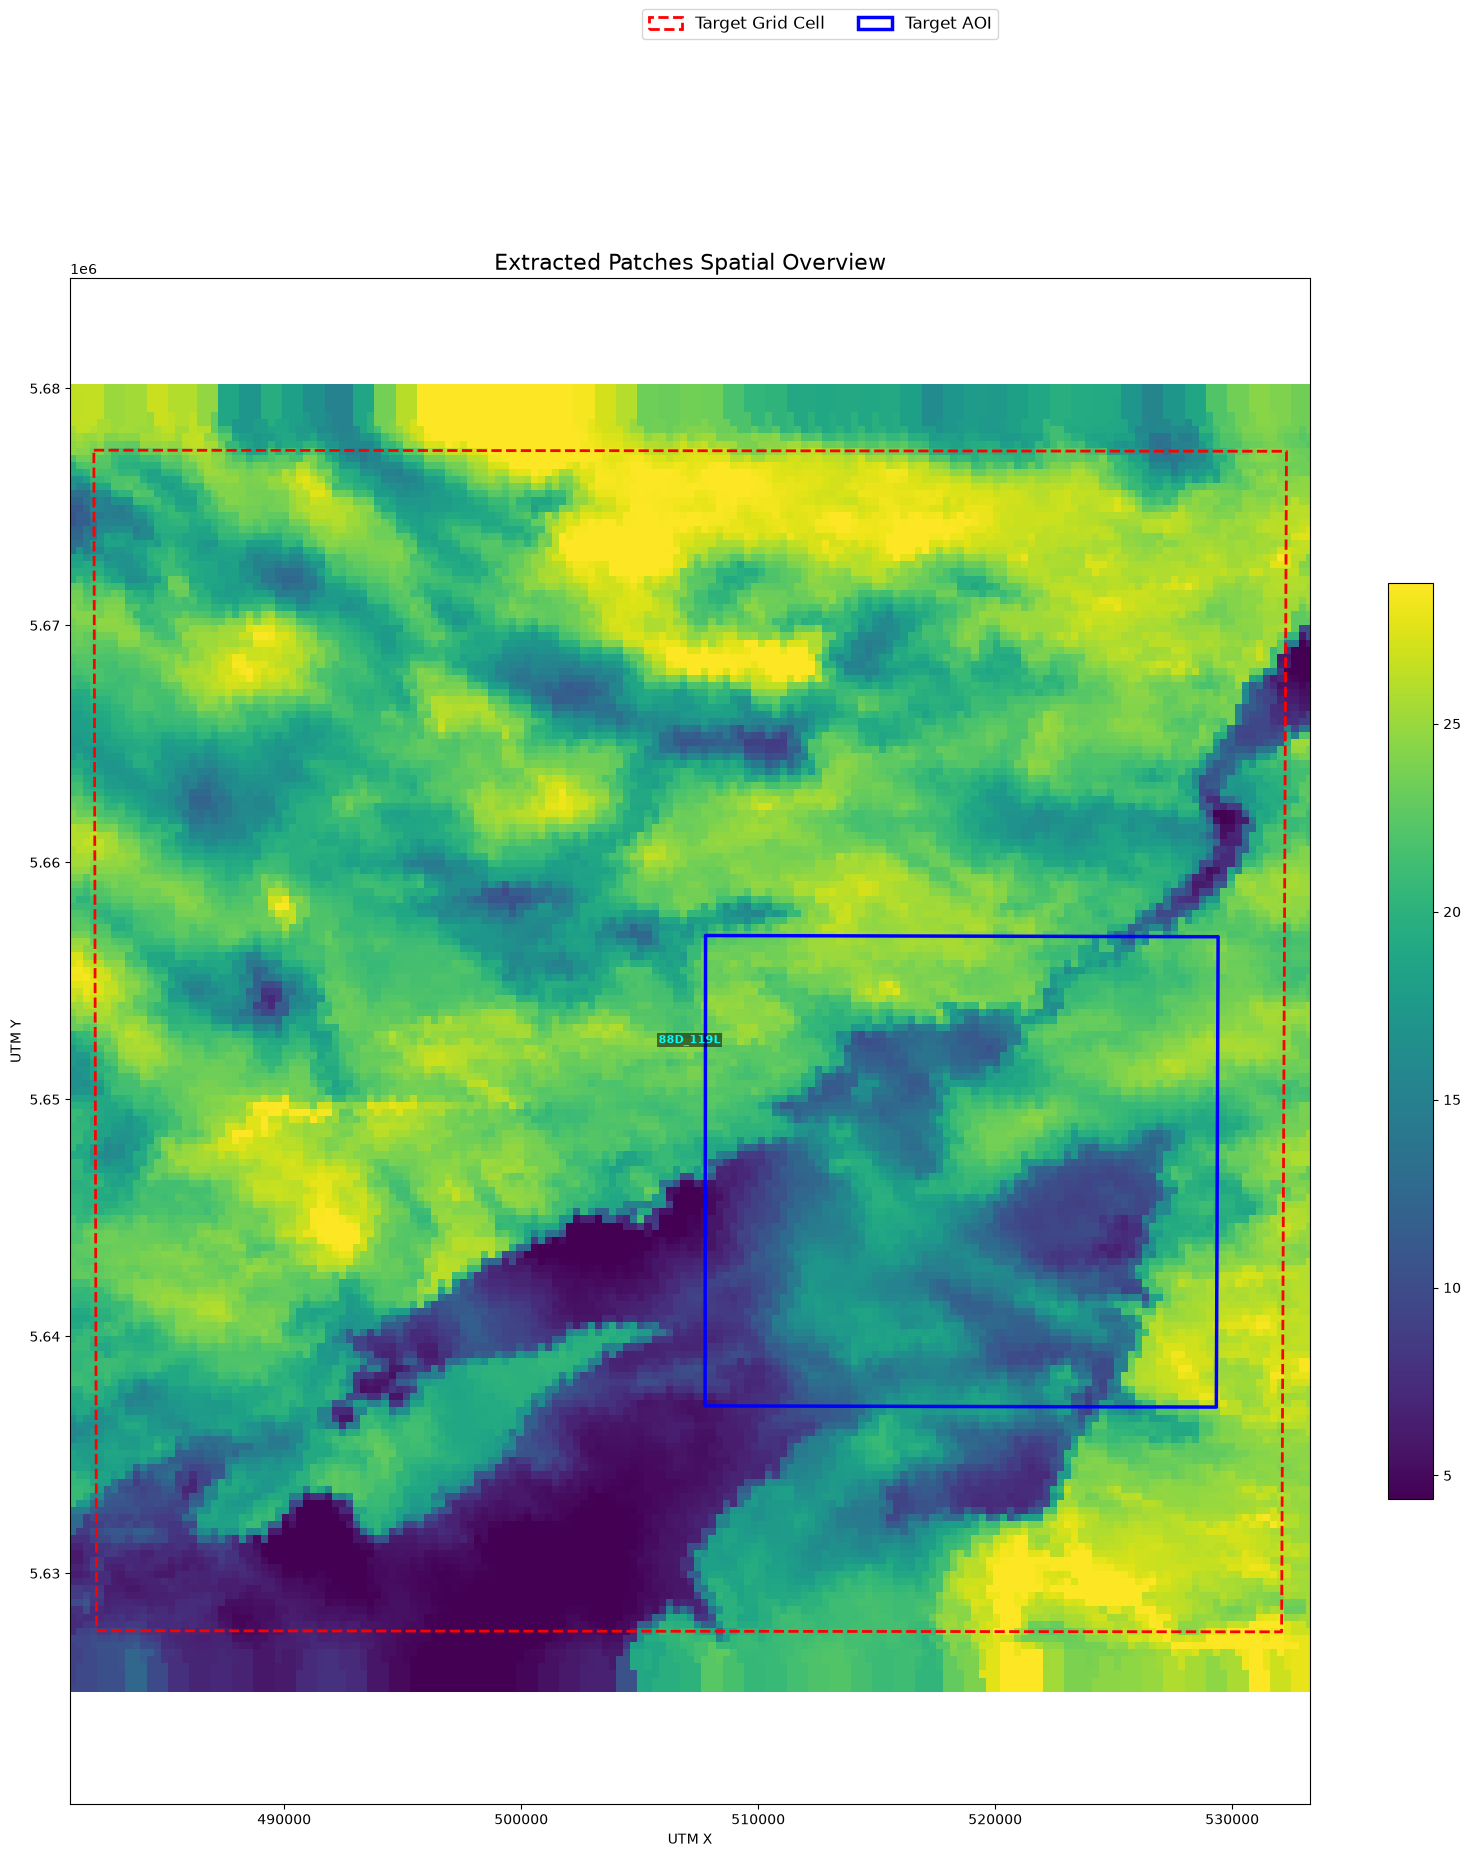

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="viridis",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)

## Visualizing OLCI results

The output GeoTIFFs contain the requested OLCI bands reprojected to a regular 300 m grid. Use the visualization helper to inspect coverage and band values.
